In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# create state
class State(TypedDict):
    number: int
    result: int
    

In [5]:
# Create Nodes

def check_number(state: State) -> State:
    return {}

def even_node(state: State) -> State:
    return {"result": "Even Node"}

def odd_node(state: State) -> State:
    return {"result": "Odd Node"}

## Router Function
def router(state: State) -> str:
    if state["number"] % 2 == 0:
        return "even_node"
    else:
        return "odd_node"

In [7]:
# Create Graph
builder = StateGraph(State)

builder.add_node("check_number", check_number)
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)

builder.add_edge(START, "check_number")

builder.add_conditional_edges("check_number", router)

builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)
graph = builder.compile()


In [9]:
graph.invoke({
    "number": 41
})

{'number': 41, 'result': 'Odd Node'}

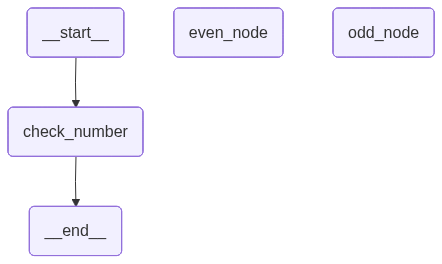

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))